# Fas C — XGBoost challenger

Mål: bygga en XGBoost-modell som **utmanare** till GLM M2 och välja en rimlig konfiguration innan jämförelsen i D1.

## Vad är XGBoost i korthet?

XGBoost bygger många små beslutsträd sekventiellt. Varje nytt träd korrigerar felen från de tidigare. Summan av alla träd ger slutprediktionen. För räknedata används `objective="count:poisson"` — modellen förutsäger log(förväntat antal skador) och jämförs med observerat antal via Poisson-likelihood.

## Nyckeldesign

| Val | Motivering |
|---|---|
| Samma features som GLM M2 (`Verksamhet`, `GeografisktOmrade`, `log(Omsättning)`) | Rättvis jämförelse mot GLM |
| `Ar` exkluderas | GLM M2 kan inte prediktera osedda år (2024/2025 skulle bli okända nivåer). XGBoost följer samma begränsning. |
| Exponering via `base_margin = log(Duration)` | Motsvarar GLM:s offset. Modellen vet då att en policy med dubbel `Duration` ska ge dubbelt förväntat skadeantal. |
| Temporell split: träna 2021-2023, validera 2024 | Identisk med B1. Test 2025 är låst och används först i D1. |
| 6 pre-picked configs + early stopping | Tillräckligt för att hitta en rimlig modell utan full hyperparameter-sökning. |

## Upplägg

1. Ladda data + feature-engineering
2. Träna **baseline**-modell med standardparametrar
3. Prova **6 alternativa konfigurationer** — välj den som har lägst valideringsdeviance
4. Spara bästa config som JSON → används oförändrad i D1

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import mean_poisson_deviance

SEED = 42
np.random.seed(SEED)

ARTIFACT_DIR = Path("./artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

print(f"xgboost: {xgb.__version__}")

xgboost: 3.2.0


## 1. Ladda data och dela upp

Samma datakontroller och split som B1.

In [2]:
data_dir = Path("../../../data")
df = pd.read_csv(data_dir / "Entreprenadförsäkring training.csv")

assert (df["Duration"] > 0).all()
assert df.isna().sum().sum() == 0

df["Ar"] = df["Ar"].astype(int)
df["log_omsattning"] = np.log(df["Omsattning"])

# Kategorinivåer låses på träningsdatan — samma mönster på val och test (D1)
CAT_COLS = ["Verksamhet", "GeografisktOmrade"]
for col in CAT_COLS:
    df[col] = df[col].astype(pd.CategoricalDtype(categories=sorted(df[col].unique())))

df_train = df[df["Ar"].isin([2021, 2022, 2023])].copy()
df_val = df[df["Ar"] == 2024].copy()

FEATURES = ["Verksamhet", "GeografisktOmrade", "log_omsattning"]

X_train = df_train[FEATURES]
y_train = df_train["AntalSkador"].values
dur_train = df_train["Duration"].values

X_val = df_val[FEATURES]
y_val = df_val["AntalSkador"].values
dur_val = df_val["Duration"].values

print(f"Träning 2021-2023: {len(df_train):,} rader ({y_train.sum():,} skador)")
print(f"Validering 2024:   {len(df_val):,} rader ({y_val.sum():,} skador)")

Träning 2021-2023: 755,691 rader (14,284 skador)
Validering 2024:   277,695 rader (5,446 skador)


## 2. Hjälpfunktioner

Tre små funktioner återanvänds överallt. Separat cell för läsbarhet.

In [3]:
def total_poisson_deviance(y_true, y_pred):
    """Total Poisson-deviance (summa, inte medel) för jämförelse med B1.
    
    sklearn.metrics.mean_poisson_deviance returnerar medelvärdet — multiplicera
    med antal observationer för att få samma storlek som statsmodels deviance.
    """
    y_pred = np.clip(y_pred, 1e-12, None)  # undvik log(0)
    return mean_poisson_deviance(y_true, y_pred) * len(y_true)


def fit_xgb(X, y, duration, X_eval, y_eval, dur_eval, params, num_rounds=2000):
    """Träna XGBoost med log(Duration) som exponering, early stopping på eval-set.
    
    base_margin = log(Duration) sätter modellens startpunkt till log-exponeringen.
    Det är exakt vad GLM gör med `offset(log(Duration))`: en dubblering av Duration
    dubblerar förväntat skadeantal.
    """
    dtrain = xgb.DMatrix(X, label=y, base_margin=np.log(duration), enable_categorical=True)
    deval = xgb.DMatrix(X_eval, label=y_eval, base_margin=np.log(dur_eval), enable_categorical=True)
    return xgb.train(
        params,
        dtrain,
        num_boost_round=num_rounds,
        evals=[(deval, "val")],
        early_stopping_rounds=50,
        verbose_eval=False,
    )


def predict_counts(booster, X, duration):
    """Prediktera förväntat skadeantal (count-space, direkt jämförbart med GLM).
    
    Kräver alltid att base_margin = log(Duration) sätts vid prediktion,
    annars tappas exponeringen och totalerna bryts.
    """
    dmat = xgb.DMatrix(X, base_margin=np.log(duration), enable_categorical=True)
    best_iter = booster.best_iteration + 1 if hasattr(booster, "best_iteration") else 0
    return booster.predict(dmat, iteration_range=(0, best_iter))

## 3. Prova 6 konfigurationer

Istället för en stor slumpmässig sökning provar vi 6 handplockade konfigurationer som täcker rimliga kombinationer av trädjup och inlärningstakt:

| Namn | `max_depth` | `learning_rate` | Kommentar |
|---|---|---|---|
| baseline | 5 | 0.05 | Standardval |
| shallow-slow | 3 | 0.03 | Grunt, försiktigt — ofta bäst när signalen är additiv |
| shallow-fast | 3 | 0.10 | Grunt men snabbt |
| medium-slow | 5 | 0.03 | Mellantjocka träd, långsam |
| deep-slow | 8 | 0.03 | Djupare träd fångar interaktioner |
| deep-fast | 8 | 0.10 | Djupa träd + snabbare inlärning |

Alla övriga parametrar hålls på vettiga defaults. Early stopping bestämmer antalet träd automatiskt.

In [4]:
COMMON = {
    "objective": "count:poisson",
    "eval_metric": "poisson-nloglik",
    "tree_method": "hist",
    "min_child_weight": 10,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "reg_lambda": 1.0,
    "seed": SEED,
    "verbosity": 0,
}

candidates = [
    {"name": "baseline",     "max_depth": 5, "learning_rate": 0.05},
    {"name": "shallow-slow", "max_depth": 3, "learning_rate": 0.03},
    {"name": "shallow-fast", "max_depth": 3, "learning_rate": 0.10},
    {"name": "medium-slow",  "max_depth": 5, "learning_rate": 0.03},
    {"name": "deep-slow",    "max_depth": 8, "learning_rate": 0.03},
    {"name": "deep-fast",    "max_depth": 8, "learning_rate": 0.10},
]

results = []
for cfg in candidates:
    params = {**COMMON, "max_depth": cfg["max_depth"], "learning_rate": cfg["learning_rate"]}
    booster = fit_xgb(X_train, y_train, dur_train, X_val, y_val, dur_val, params, num_rounds=3000)
    val_pred = predict_counts(booster, X_val, dur_val)

    results.append({
        "namn": cfg["name"],
        "max_depth": cfg["max_depth"],
        "learning_rate": cfg["learning_rate"],
        "best_iter": booster.best_iteration,
        "val_deviance": total_poisson_deviance(y_val, val_pred),
        "portfolio_err_pct": 100 * (val_pred.sum() - y_val.sum()) / y_val.sum(),
    })
    print(f"{cfg['name']:14s}  val deviance = {results[-1]['val_deviance']:,.1f}  "
          f"(best_iter={booster.best_iteration}, portföljfel={results[-1]['portfolio_err_pct']:+.2f}%)")

results_df = pd.DataFrame(results).sort_values("val_deviance").reset_index(drop=True)
display(results_df.style.format({
    "learning_rate": "{:.3f}",
    "val_deviance": "{:,.1f}",
    "portfolio_err_pct": "{:+.2f}",
}))

baseline        val deviance = 40,932.7  (best_iter=413, portföljfel=-3.43%)


shallow-slow    val deviance = 40,918.5  (best_iter=815, portföljfel=-3.55%)


shallow-fast    val deviance = 40,918.1  (best_iter=231, portföljfel=-3.55%)


medium-slow     val deviance = 40,932.2  (best_iter=639, portföljfel=-3.27%)


deep-slow       val deviance = 40,999.0  (best_iter=525, portföljfel=-1.86%)


deep-fast       val deviance = 41,003.9  (best_iter=149, portföljfel=-1.23%)


,namn,max_depth,learning_rate,best_iter,val_deviance,portfolio_err_pct
0,shallow-fast,3,0.100,231,"40,918.1",-3.55
1,shallow-slow,3,0.030,815,"40,918.5",-3.55
2,medium-slow,5,0.030,639,"40,932.2",-3.27
3,baseline,5,0.050,413,"40,932.7",-3.43
4,deep-slow,8,0.030,525,"40,999.0",-1.86
5,deep-fast,8,0.100,149,"41,003.9",-1.23


## 4. Spara bästa konfiguration

JSON-filen läses oförändrad i D1 för slutjämförelsen mot GLM.

In [5]:
best = results_df.iloc[0].to_dict()

best_config = {
    "hyperparams": {
        **COMMON,
        "max_depth": int(best["max_depth"]),
        "learning_rate": float(best["learning_rate"]),
    },
    "num_boost_round": int(best["best_iter"]) + 1,
    "val_deviance": float(best["val_deviance"]),
    "portfolio_err_pct": float(best["portfolio_err_pct"]),
    "valt_namn": best["namn"],
}

with open(ARTIFACT_DIR / "C-best-config.json", "w") as f:
    json.dump(best_config, f, indent=2)

results_df.to_csv(ARTIFACT_DIR / "C-candidates.csv", index=False)

print(f"Bästa: {best['namn']}")
print(json.dumps(best_config, indent=2))

Bästa: shallow-fast
{
  "hyperparams": {
    "objective": "count:poisson",
    "eval_metric": "poisson-nloglik",
    "tree_method": "hist",
    "min_child_weight": 10,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "reg_lambda": 1.0,
    "seed": 42,
    "verbosity": 0,
    "max_depth": 3,
    "learning_rate": 0.1
  },
  "num_boost_round": 232,
  "val_deviance": 40918.10951448977,
  "portfolio_err_pct": -3.547122099361917,
  "valt_namn": "shallow-fast"
}


## 5. Feature importance (för bästa modellen)

Gain mäter hur mycket varje variabel bidrog till att minska Poisson-felet när modellen delade upp datan. Högre = viktigare.

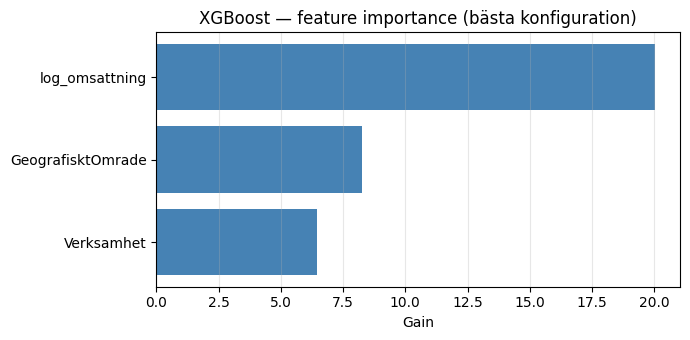

,Feature,Gain
0,log_omsattning,20.037285
1,GeografisktOmrade,8.259920
2,Verksamhet,6.458417


In [6]:
# Träna om bästa modellen för att få feature importance
best_booster = fit_xgb(
    X_train, y_train, dur_train, X_val, y_val, dur_val,
    best_config["hyperparams"], num_rounds=best_config["num_boost_round"],
)

importance = best_booster.get_score(importance_type="gain")
imp_df = pd.DataFrame({"Feature": list(importance.keys()), "Gain": list(importance.values())})
imp_df = imp_df.sort_values("Gain", ascending=True)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(imp_df["Feature"], imp_df["Gain"], color="steelblue")
ax.set_xlabel("Gain")
ax.set_title("XGBoost — feature importance (bästa konfiguration)")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

display(imp_df.sort_values("Gain", ascending=False).reset_index(drop=True))

## Slutsats

Bästa konfigurationen är sparad i `./artifacts/C-best-config.json`. Den läses oförändrad in i D1, där både GLM M2 och XGBoost jämförs på 2024-validering och på låst 2025-testset.

**Förväntan inför D1:** Eftersom grunda träd ofta vinner (signalen är nästan additiv i den här datan) är det troligt att XGBoost presterar *marginellt* bättre än GLM på deviance — inte dramatiskt. GLM M2 förblir konkurrenskraftig tack vare enkel tolkning och stabila rate ratios.